# VOL Forecast with LSTM and Garch

https://eudl.eu/pdf/10.4108/eai.6-1-2023.2330313


# Does not work too well with daily and hourly data needs 5 minute intervals


In [4]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [5]:
# ---------- Step 1: lock project design ----------
INTERVAL = "1h"         
LOOKBACK_PERIOD = "730d" 
GARCH_WINDOW = 252       

print(f"Universe size: {len(universe)}")
print(f"Interval: {INTERVAL}")
print(f"Lookback period: {LOOKBACK_PERIOD}")
print(f"GARCH rolling window: {GARCH_WINDOW}")

Universe size: 102
Interval: 1h
Lookback period: 730d
GARCH rolling window: 252


In [6]:
# ---------- Step 2: download hourly data ----------

def download_hourly_data(tickers, period="730d", interval="1h"):
    data = yf.download(
        tickers=tickers,
        period=period,
        interval=interval,
        group_by="ticker",
        auto_adjust=False,
        progress=True,
        threads=True
    )
    return data


raw_data = download_hourly_data(universe, LOOKBACK_PERIOD, INTERVAL)

print("Download complete")

[*************         27%                       ]  28 of 102 completed$JNPR: possibly delisted; no price data found  (period=730d) (Yahoo error = "No data found, symbol may be delisted")
$ZI: possibly delisted; no price data found  (period=730d) (Yahoo error = "No data found, symbol may be delisted")
[*******************   40%                       ]  41 of 102 completed$ANSS: possibly delisted; no price data found  (period=730d) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  102 of 102 completed

3 Failed downloads:
['JNPR', 'ZI', 'ANSS']: possibly delisted; no price data found  (period=730d) (Yahoo error = "No data found, symbol may be delisted")


Download complete


In [7]:
# ---------- Step 2: clean and structure ----------

def extract_close_prices(raw_data, tickers):
    close_dict = {}

    for ticker in tickers:
        try:
            df = raw_data[ticker].copy()

            # Use Close only (paper uses price, not adjusted)
            close = df["Close"].copy()

            # Drop NaNs
            close = close.dropna()

            # Remove duplicates
            close = close[~close.index.duplicated(keep='first')]

            close_dict[ticker] = close

        except Exception as e:
            print(f"Skipping {ticker}: {e}")

    return close_dict


price_dict = extract_close_prices(raw_data, universe)

print(f"Assets successfully downloaded: {len(price_dict)}")

# ---------- align into one DataFrame ----------

price_df = pd.concat(price_dict, axis=1)

# Drop timestamps where too many assets are missing
price_df = price_df.dropna(thresh=int(0.7 * len(price_dict)))

print(price_df.shape)
print(price_df.head())

Assets successfully downloaded: 102
(5068, 102)
                                NVDA        AMD       AVGO         MU  \
2023-05-01 13:30:00+00:00  28.365000  88.743202  62.815998  62.785000   
2023-05-01 14:30:00+00:00  28.514999  89.230003  63.062000  62.459999   
2023-05-01 15:30:00+00:00  28.680012  90.033096  63.236900  62.715000   
2023-05-01 16:30:00+00:00  28.844000  90.089996  63.362499  62.509998   
2023-05-01 17:30:00+00:00  28.878500  89.779999  63.657001  62.470001   

                                 AMAT       LRCX        KLAC         ADI  \
2023-05-01 13:30:00+00:00  112.260002  52.237999  383.350006  181.039993   
2023-05-01 14:30:00+00:00  112.464996  52.322998  383.779999  181.360001   
2023-05-01 15:30:00+00:00  113.309998  52.555000  386.269989  181.809998   
2023-05-01 16:30:00+00:00  113.010002  52.515999  386.059998  182.360001   
2023-05-01 17:30:00+00:00  113.190102  52.549999  386.309998  182.169998   

                                  TXN       INTC  ...   

In [8]:
# ---------- Step 3: compute hourly log returns ----------

# log returns
returns_df = 100 * np.log(price_df / price_df.shift(1))

# drop first row (NaN from shift)
returns_df = returns_df.iloc[1:]

print("Returns shape:", returns_df.shape)
print(returns_df.head())
print(returns_df.describe())

Returns shape: (5067, 102)
                               NVDA       AMD      AVGO        MU      AMAT  \
2023-05-01 14:30:00+00:00  0.527426  0.547051  0.390859 -0.518985  0.182440   
2023-05-01 15:30:00+00:00  0.577018  0.896000  0.276962  0.407432  0.748537   
2023-05-01 16:30:00+00:00  0.570157  0.063179  0.198420 -0.327414 -0.265107   
2023-05-01 17:30:00+00:00  0.119538 -0.344691  0.463713 -0.064006  0.159239   
2023-05-01 18:30:00+00:00  0.112475 -0.167106 -0.048714 -0.096094 -0.097317   

                               LRCX      KLAC       ADI       TXN      INTC  \
2023-05-01 14:30:00+00:00  0.162583  0.112104  0.176605 -0.072000 -0.730377   
2023-05-01 15:30:00+00:00  0.442424  0.646711  0.247816  0.179890 -0.101125   
2023-05-01 16:30:00+00:00 -0.074238 -0.054379  0.302059 -0.002998 -0.475919   
2023-05-01 17:30:00+00:00  0.064722  0.064736 -0.104245 -0.254938  0.082215   
2023-05-01 18:30:00+00:00 -0.085673 -0.147661  0.202898  0.006003 -0.115122   

                       

Assets after cleaning: 99
RV shape: (730, 99)


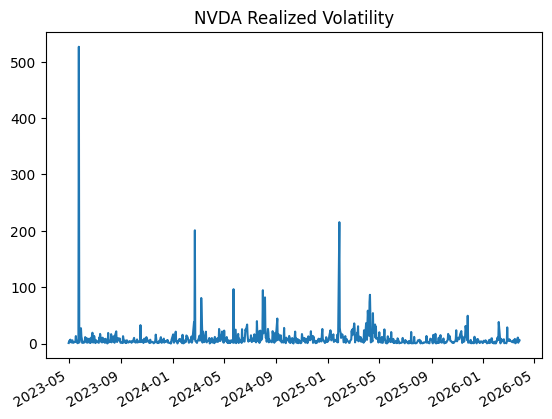

In [9]:
# ---------- remove broken assets ----------
returns_df = returns_df.dropna(axis=1, how='all')

print("Assets after cleaning:", returns_df.shape[1])
# square returns
sq_returns = returns_df ** 2

# ---------- compute realized volatility ----------

rv_df = sq_returns.groupby(sq_returns.index.date).sum()

# convert index back to datetime
rv_df.index = pd.to_datetime(rv_df.index)

print("RV shape:", rv_df.shape)
rv_df.head()

rv_df["NVDA"].plot(title="NVDA Realized Volatility")
plt.show()

In [10]:
# ---------- Step 5: extract daily close prices ----------


# take last price of each day (this is the close)
daily_close = price_df.groupby(price_df.index.date).last()

# convert index to datetime
daily_close.index = pd.to_datetime(daily_close.index)

print("Daily close shape:", daily_close.shape)
daily_close.head()
# ---------- compute daily returns ----------

daily_returns = 100 * np.log(daily_close / daily_close.shift(1))

# drop first row (NaN)
daily_returns = daily_returns.iloc[1:]

print("Daily returns shape:", daily_returns.shape)
daily_returns.head()

Daily close shape: (730, 102)
Daily returns shape: (729, 102)


,NVDA,AMD,AVGO,MU,AMAT,LRCX,KLAC,ADI,TXN,INTC,...,RDWR,ATEN,NTCT,CVLT,RPD,LDOS,BAH,IBM,JNPR,CIEN
2023-05-02,-2.451099,0.272855,-4.131061,-0.677823,-0.675313,-0.394005,-1.581319,0.639014,-1.651637,-1.732223,...,-2.780059,-2.219577,-2.902033,5.128472,-4.921094,-15.707053,-4.557751,-0.740296,NaN,-3.235668
2023-05-03,-1.460455,-9.740325,0.132224,-1.612284,0.984786,-1.370015,-0.042302,-0.704783,-0.354429,2.979365,...,-10.189250,0.355621,-0.459943,-0.358893,-0.583723,0.346748,0.859854,-1.367574,NaN,-0.853748
2023-05-04,-0.863399,5.983825,-0.498787,-0.650610,-0.726567,-0.483969,-1.349773,-0.599411,-0.651036,1.874045,...,2.798168,-0.391253,8.078118,-0.458639,-1.155827,-1.783646,-1.455323,-0.715332,NaN,-1.111748
2023-05-05,3.976194,3.673047,3.256452,1.207259,3.159863,3.354742,3.308466,1.110738,2.209075,-0.868035,...,4.847473,-2.015905,4.875641,0.409602,2.800936,1.709447,1.069304,0.909536,NaN,0.568765
2023-05-08,1.639221,5.626760,-0.177893,-0.630552,-0.258818,-0.549003,-0.546039,0.649736,-1.026857,-0.599142,...,1.926636,0.000000,-0.847319,0.814204,1.534508,-2.188818,-1.777631,-0.250919,NaN,-0.614407


In [11]:
# ---------- align assets between RV and returns ----------

common_assets = rv_df.columns.intersection(daily_returns.columns)

rv_df = rv_df[common_assets]
daily_returns = daily_returns[common_assets]

print("Assets after alignment:", len(common_assets))

# ---------- align dates ----------

common_dates = rv_df.index.intersection(daily_returns.index)

rv_df = rv_df.loc[common_dates]
daily_returns = daily_returns.loc[common_dates]
rv_df = rv_df.rolling(3).mean()
print("RV shape:", rv_df.shape)
print("Returns shape:", daily_returns.shape)

Assets after alignment: 99
RV shape: (729, 99)
Returns shape: (729, 99)


In [12]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# pick one asset for sanity check
asset = "NVDA"

r = daily_returns[asset].dropna()
rv = rv_df[asset].dropna()

# ---------- Jarque-Bera (normality test) ----------
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(r)

print("Jarque-Bera p-value:", jb_pvalue)
print("Skew:", skew)
print("Kurtosis:", kurtosis)

# ---------- Ljung-Box (autocorrelation test) ----------
lb = acorr_ljungbox(rv, lags=[5, 10, 20], return_df=True)

print("\nLjung-Box test on RV:")
print(lb)


# Problem is that hourly data doesnt follow as strong autocorrelation

Jarque-Bera p-value:

 0.0
Skew: 0.3630840898957767
Kurtosis: 10.049473455939973

Ljung-Box test on RV:
       lb_stat      lb_pvalue
5   519.596768  4.696984e-110
10  522.202630  7.922154e-106
20  529.553736   1.862019e-99


In [13]:
from arch import arch_model

# ---------- Step 7: rolling sGARCH ----------

def rolling_sgarch(returns, window=252):
    forecasts = []

    for t in range(window, len(returns) - 1):
        train = returns.iloc[t-window:t]

        try:
            model = arch_model(
                train,
                vol='GARCH',
                p=1,
                q=1,
                dist='ged'   # paper uses GED
            )

            res = model.fit(disp='off')

            # forecast next step variance
            fcast = res.forecast(horizon=1)

            sigma2 = fcast.variance.iloc[-1, 0]

            forecasts.append(np.sqrt(sigma2))

        except:
            forecasts.append(np.nan)

    return pd.Series(forecasts, index=returns.index[window:-1])
asset = "NVDA"

sgarch_nvda = rolling_sgarch(daily_returns[asset].dropna())

print(sgarch_nvda.head())

2024-05-02    2.819608
2024-05-03    2.828367
2024-05-06    2.834105
2024-05-07    2.843333
2024-05-08    2.832488
dtype: float64


In [14]:
len(sgarch_nvda)

476

In [15]:
print(sgarch_nvda.describe())

count    476.000000
mean       2.996277
std        0.762350
min        1.800427
25%        2.404425
50%        2.911821
75%        3.329839
max        6.802235
dtype: float64


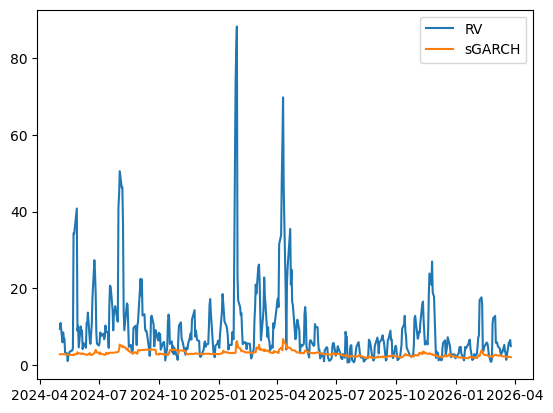

In [16]:
plt.plot(rv_df[asset].iloc[252:-1], label="RV")
plt.plot(sgarch_nvda, label="sGARCH")
plt.legend()
plt.show()

In [17]:
# ---------- Step 8: rolling eGARCH ----------

def rolling_egarch(returns, window=252):
    forecasts = []

    for t in range(window, len(returns) - 1):
        train = returns.iloc[t-window:t]

        # SCALE RETURNS (CRITICAL FIX)
        train = train / 10

        try:
            model = arch_model(
                train,
                vol='EGARCH',
                p=1,
                q=1,
                dist='normal'   # switch from GED → more stable
            )

            res = model.fit(disp='off')

            fcast = res.forecast(horizon=1)

            sigma2 = fcast.variance.iloc[-1, 0]

            sigma = np.sqrt(sigma2)

            # UNDO scaling
            sigma = sigma * 10

            # CLIP extreme explosions
            if sigma > 20 or np.isnan(sigma):
                forecasts.append(np.nan)
            else:
                forecasts.append(sigma)

        except:
            forecasts.append(np.nan)

    return pd.Series(forecasts, index=returns.index[window:-1])

egarch_nvda = rolling_egarch(daily_returns["NVDA"].dropna())

print(egarch_nvda.describe())

C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09028. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09026. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Ro

count    4.750000e+02
mean     2.906788e+00
std      9.365393e-01
min      1.087369e-31
25%      2.381297e+00
50%      2.874622e+00
75%      3.271902e+00
max      1.223995e+01
dtype: float64


C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.07642. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.07625. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Ro

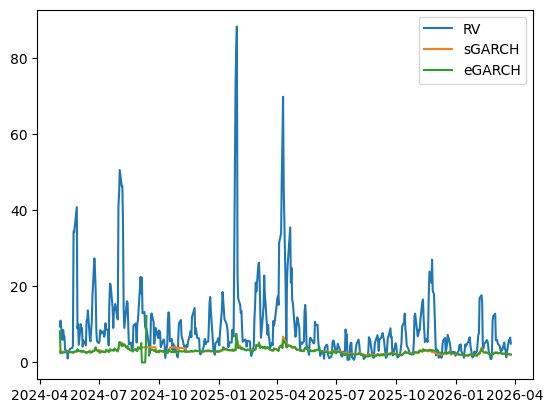

In [18]:
plt.plot(rv_df["NVDA"].iloc[252:-1], label="RV")
plt.plot(sgarch_nvda, label="sGARCH")
plt.plot(egarch_nvda, label="eGARCH")

plt.legend()
plt.show()

In [19]:
# ---------- Step 9: rolling tGARCH (GJR-GARCH) ----------

def rolling_tgarch(returns, window=252):
    forecasts = []

    for t in range(window, len(returns) - 1):
        train = returns.iloc[t-window:t]

        # SCALE (same as eGARCH for stability)
        train = train / 10

        try:
            model = arch_model(
                train,
                vol='GARCH',
                p=1,
                o=1,   # threshold term
                q=1,
                dist='normal'
            )

            res = model.fit(disp='off')

            fcast = res.forecast(horizon=1)

            sigma2 = fcast.variance.iloc[-1, 0]

            sigma = np.sqrt(sigma2)

            # UNDO scaling
            sigma = sigma * 10

            # CLIP extremes
            if sigma > 20 or np.isnan(sigma):
                forecasts.append(np.nan)
            else:
                forecasts.append(sigma)

        except:
            forecasts.append(np.nan)

    return pd.Series(forecasts, index=returns.index[window:-1])

In [20]:
tgarch_nvda = rolling_tgarch(daily_returns["NVDA"].dropna())

print(tgarch_nvda.describe())

C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09028. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.09026. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Ro

count    476.000000
mean       3.014146
std        1.081512
min        1.835560
25%        2.424717
50%        2.811718
75%        3.158324
max       15.724919
dtype: float64


C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.06505. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.06502. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Nish\AppData\Ro

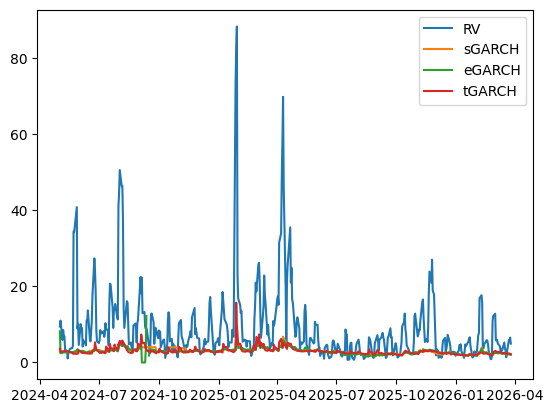

In [21]:
plt.plot(rv_df["NVDA"].iloc[252:-1], label="RV")
plt.plot(sgarch_nvda, label="sGARCH")
plt.plot(egarch_nvda, label="eGARCH")
plt.plot(tgarch_nvda, label="tGARCH")

plt.legend()
plt.show()

In [22]:
# ---------- fix RV outliers ----------

# clip per asset at 99th percentile
rv_df_clipped = rv_df.copy()

for col in rv_df.columns:
    upper = rv_df[col].quantile(0.99)
    rv_df_clipped[col] = np.clip(rv_df[col], None, upper)

# use this going forward
rv_df = rv_df_clipped

In [23]:
# ---------- Step 10: build RV-LSTM dataset ----------

SEQUENCE_LENGTH = 20

def build_lstm_dataset(series, seq_len=20):
    X = []
    y = []

    values = series.values

    for i in range(seq_len, len(values) - 1):
        X.append(values[i-seq_len:i])
        y.append(values[i+1])  # predict next day

    return np.array(X), np.array(y)

rv_series = rv_df["NVDA"].dropna()

X_rv, y_rv = build_lstm_dataset(rv_series, SEQUENCE_LENGTH)

print("X shape:", X_rv.shape)
print("y shape:", y_rv.shape)

X shape: (706, 20)
y shape: (706,)


In [24]:
print("First X:", X_rv[0])
print("First y:", y_rv[0])

First X: [ 3.69156804  4.84565108  3.68974089  4.58119875  4.18794373  4.14752483
  2.95132443  1.97673827  2.45144164  3.57337299  7.04013343  7.13758205
  5.77639919  1.73653024  3.49557496 70.85905828 70.85905828 70.85905828
 13.79600975 16.02534011]
First y: 4.232216994440417


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_rv = scaler.fit_transform(X_rv.reshape(-1, 1)).reshape(X_rv.shape)
y_rv = scaler.fit_transform(y_rv.reshape(-1, 1)).flatten()

In [26]:
# ---------- Step 11: build sGARCH-LSTM dataset ----------

def build_garch_lstm_dataset(garch_series, rv_series, seq_len=20):
    X = []
    y = []

    # align indices
    common_index = garch_series.index.intersection(rv_series.index)

    garch_series = garch_series.loc[common_index]
    rv_series = rv_series.loc[common_index]

    g_vals = garch_series.values
    rv_vals = rv_series.values

    for i in range(seq_len, len(g_vals) - 1):
        X.append(g_vals[i-seq_len:i])
        y.append(rv_vals[i+1])  # predict next day RV

    return np.array(X), np.array(y)


sgarch_series = sgarch_nvda.dropna()
rv_series = rv_df["NVDA"].loc[sgarch_series.index]

X_sg, y_sg = build_garch_lstm_dataset(sgarch_series, rv_series, SEQUENCE_LENGTH)

print("X_sg shape:", X_sg.shape)
print("y_sg shape:", y_sg.shape)

X_sg shape: (455, 20)
y_sg shape: (455,)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sg = scaler.fit_transform(X_sg.reshape(-1, 1)).reshape(X_sg.shape)
y_sg = scaler.fit_transform(y_sg.reshape(-1, 1)).flatten()


In [28]:
# ---------- Step 12: build eGARCH-LSTM dataset ----------

egarch_series = egarch_nvda.dropna()
rv_df["NVDA"].loc[egarch_series.index]

# align with RV
rv_series = rv_df["NVDA"].loc[egarch_series.index]

X_eg, y_eg = build_garch_lstm_dataset(
    egarch_series,
    rv_series,
    SEQUENCE_LENGTH
)

print("X_eg shape:", X_eg.shape)
print("y_eg shape:", y_eg.shape)

X_eg shape: (454, 20)
y_eg shape: (454,)


In [29]:
# ---------- Step 13: build tGARCH-LSTM dataset ----------

tgarch_series = tgarch_nvda.dropna()

# align with RV
rv_series = rv_df["NVDA"].loc[tgarch_series.index]

X_tg, y_tg = build_garch_lstm_dataset(
    tgarch_series,
    rv_series,
    SEQUENCE_LENGTH
)

print("X_tg shape:", X_tg.shape)
print("y_tg shape:", y_tg.shape)


X_tg shape: (455, 20)
y_tg shape: (455,)


In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [31]:
# ---------- Step 14: helper functions ----------

def scale_lstm_data(X_train, X_test, y_train, y_test):
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    # fit on training only
    X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
    X_test_scaled  = x_scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_test_scaled  = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, x_scaler, y_scaler


def reshape_for_lstm(X):
    return X.reshape((X.shape[0], X.shape[1], 1))


def train_test_split_time_series(X, y, train_frac=0.9):
    split_idx = int(len(X) * train_frac)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    return X_train, X_test, y_train, y_test


def build_lstm_model(seq_len):
    model = Sequential([
        LSTM(32, input_shape=(seq_len, 1)),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model


def fit_lstm_model(X, y, seq_len=20, epochs=50, batch_size=16):
    X_train, X_test, y_train, y_test = train_test_split_time_series(X, y, train_frac=0.9)

    X_train, X_test, y_train, y_test, x_scaler, y_scaler = scale_lstm_data(
        X_train, X_test, y_train, y_test
    )

    X_train = reshape_for_lstm(X_train)
    X_test  = reshape_for_lstm(X_test)

    model = build_lstm_model(seq_len)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    return {
        "model": model,
        "history": history,
        "y_test": y_test_actual,
        "y_pred": y_pred
    }


# ---------- train all 4 LSTMs on NVDA ----------

rv_result = fit_lstm_model(X_rv, y_rv, seq_len=SEQUENCE_LENGTH)
sg_result = fit_lstm_model(X_sg, y_sg, seq_len=SEQUENCE_LENGTH)
eg_result = fit_lstm_model(X_eg, y_eg, seq_len=SEQUENCE_LENGTH)
tg_result = fit_lstm_model(X_tg, y_tg, seq_len=SEQUENCE_LENGTH)

print("RV-LSTM test preds:", len(rv_result["y_pred"]))
print("sGARCH-LSTM test preds:", len(sg_result["y_pred"]))
print("eGARCH-LSTM test preds:", len(eg_result["y_pred"]))
print("tGARCH-LSTM test preds:", len(tg_result["y_pred"]))

C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RV-LSTM test preds: 71
sGARCH-LSTM test preds: 46
eGARCH-LSTM test preds: 46
tGARCH-LSTM test preds: 46


In [32]:
# ---------- build hybrid forecast ----------

min_len = min(
    len(rv_result["y_pred"]),
    len(sg_result["y_pred"]),
    len(eg_result["y_pred"]),
    len(tg_result["y_pred"])
)

rv_pred = rv_result["y_pred"][-min_len:]
sg_pred = sg_result["y_pred"][-min_len:]
eg_pred = eg_result["y_pred"][-min_len:]
tg_pred = tg_result["y_pred"][-min_len:]

y_true = rv_result["y_test"][-min_len:]  # use RV-LSTM target as common target

hybrid_pred = (rv_pred + sg_pred + eg_pred + tg_pred) / 4

print("Hybrid length:", len(hybrid_pred))

Hybrid length: 46


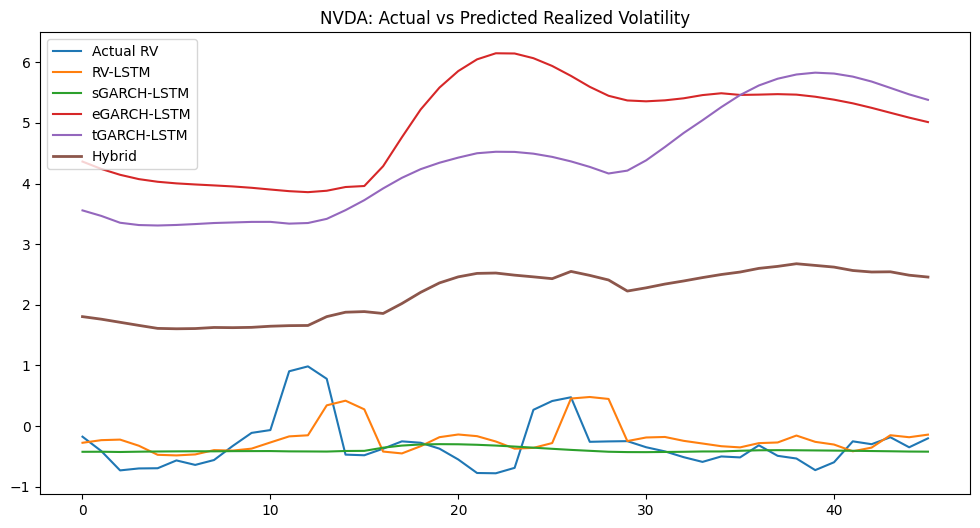

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(y_true, label="Actual RV")
plt.plot(rv_pred, label="RV-LSTM")
plt.plot(sg_pred, label="sGARCH-LSTM")
plt.plot(eg_pred, label="eGARCH-LSTM")
plt.plot(tg_pred, label="tGARCH-LSTM")
plt.plot(hybrid_pred, label="Hybrid", linewidth=2)
plt.legend()
plt.title("NVDA: Actual vs Predicted Realized Volatility")
plt.show()

In [34]:
# rebuild RV dataset (no scaling)
rv_series = rv_df["NVDA"].dropna()

X_rv, y_rv = build_lstm_dataset(rv_series, SEQUENCE_LENGTH)

rv_result = fit_lstm_model(X_rv, y_rv, seq_len=SEQUENCE_LENGTH)


min_len = min(
    len(rv_result["y_pred"]),
    len(sg_result["y_pred"]),
    len(eg_result["y_pred"]),
    len(tg_result["y_pred"])
)

rv_pred = rv_result["y_pred"][-min_len:]
sg_pred = sg_result["y_pred"][-min_len:]
eg_pred = eg_result["y_pred"][-min_len:]
tg_pred = tg_result["y_pred"][-min_len:]

y_true = rv_result["y_test"][-min_len:]

hybrid_pred = (rv_pred + sg_pred + eg_pred + tg_pred) / 4

C:\Users\Nish\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
# ---------- convert RV to volatility ----------

hybrid_vol = np.sqrt(np.maximum(hybrid_pred, 0))

# use same aligned window as predictions
returns_aligned = daily_returns["NVDA"].iloc[-len(hybrid_vol):]

mu = returns_aligned.mean()
print("Mean return:", mu)

# ---------- compute VaR ----------

z = -1.645  # 95% VaR

var_95 = mu + z * hybrid_vol

print("VaR sample:", var_95[:5])

# ---------- trading signal ----------

threshold = -2  # slightly stricter than paper

signal = (var_95 > threshold).astype(int)

print("Signal sample:", signal[:10])


# ---------- strategy returns ----------

strategy_returns = signal * returns_aligned.values

# cumulative return
cum_returns = np.cumsum(strategy_returns)

print("Final cumulative return:", cum_returns[-1])

# ---------- strategy returns ----------

strategy_returns = signal * returns_aligned.values

# cumulative return
cum_returns = np.cumsum(strategy_returns)

print("Final cumulative return:", cum_returns[-1])

Mean return: -0.19671465809883543
VaR sample: [-3.01272418 -3.02256014 -3.01620318 -2.94695904 -2.82226755]
Signal sample: [0 0 0 0 0 0 0 0 0 0]
Final cumulative return: 0.0
Final cumulative return: 0.0


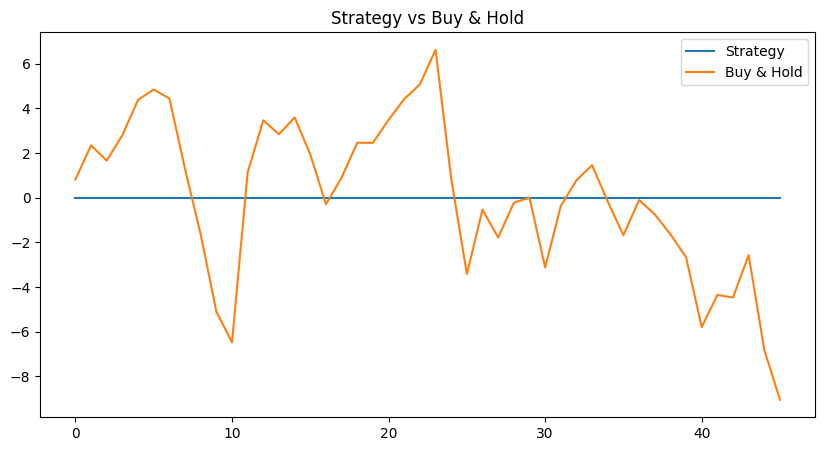

In [36]:
plt.figure(figsize=(10,5))
plt.plot(cum_returns, label="Strategy")
plt.plot(np.cumsum(returns_aligned.values), label="Buy & Hold")
plt.legend()
plt.title("Strategy vs Buy & Hold")
plt.show()